In [1]:
from Gen_Unfold.src import curve_prediction

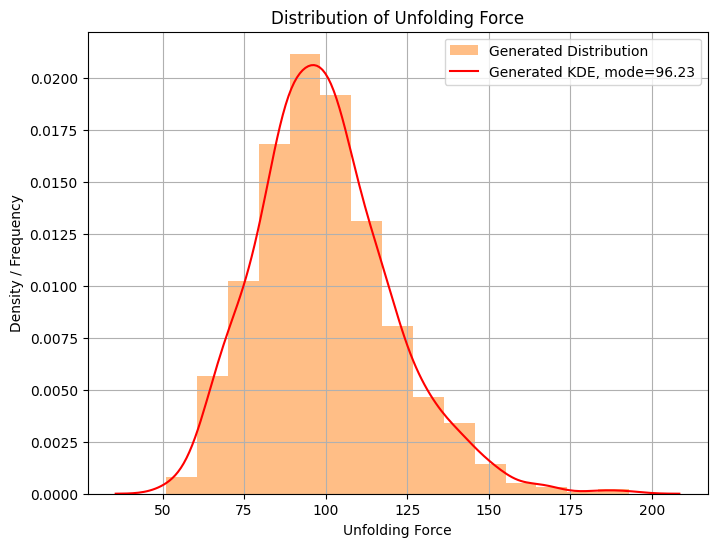

In [2]:
# Inference with a pretrained model
pretrained_model_path = r"../trained_models/best_model.pt" # Path to the pretrained model
num_samples = 1024 # Number of samples to generate

# Predict force-extension curves for a given protein structure
gen_curves, mechanical_properties = curve_prediction(pretrained_model_path,
                 pdb_id_or_path=r'./1emb/1emb.cif', # Path to the protein structure file
                 chain='A', # Chain identifier
                 feature_path=r'./', # Path to the features
                 save_path=r'./1emb/predictions.npy', # Path to save the predictions
                 num_samples=num_samples,
                 device='cuda', # Device to use for computation
                 eta=0.0, # Noise scale
                 )

In [5]:
from transformers import EsmTokenizer, EsmModel

# If you want to predict new protein without pre-extracted features, you should set the pretrained_esm_model
model_name = "facebook/esm2_t33_650M_UR50D" # Pretrained ESM model name
cache_dir = ... # Path to cache the pretrained ESM model
pretrained_model_path = r"../trained_models/best_model.pt" # Path to the pretrained model

# Protein structure inference parameters
pdb_id_or_path= ... # Path to the protein structure file, e.g., r'./data/1dxx.cif'
chain= ... # Chain identifier, e.g., 'A'
feature_path= ... # Path to the features, e.g., r'./'
save_path= ... # Path to save the predictions, e.g., r'./1dxx/predictions.npy'

num_samples = 1024 # Number of samples to generate
eta = 0.0 # Noise scale
device='cuda'

# Load the pretrained ESM model
tokenizer = EsmTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = EsmModel.from_pretrained(model_name, add_pooling_layer=False, cache_dir=cache_dir)

# Predict force-extension curves for a given protein structure without pre-extracted features
parameters = {'model': model, 'tokenizer': tokenizer}
gen_curves, mechanical_properties = curve_prediction(pretrained_model_path,
                 pdb_id_or_path=pdb_id_or_path, # Path to the protein structure file
                 chain=chain, # Chain identifier
                 feature_path=feature_path, # Path to the features
                 save_path=save_path, # Path to save the predictions
                 num_samples=num_samples,
                 device=device, # Device to use for computation
                 eta=eta, # Noise scale
                 parameters=parameters
                 )

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument index in method wrapper_CUDA__index_select)